# 🧬 Python for qPCR Data Analysis
### Workshop: Technical Skills Series (TSS)
#### Session: Python for Data Analysis & Automation
· Dept. of Bioengineering, Northeastern University · March 27, 2026

---
**What you'll do:**
1. Learn Python basics (variables, lists, DataFrames)
2. Read and inspect real qPCR data
3. Find and fix data quality issues
4. Run the ΔΔCt pipeline
5. Visualize and statistically test the results

**Run each cell in order** with `Shift + Enter`.


---
## Part A: Python Basics — Execute & Learn
Run each cell below to get familiar with Python syntax.


In [9]:
# ── Import the packages we'll use ──
# pandas:     read/manipulate tables (DataFrames)
# numpy:      math operations (mean, std, etc.)
# matplotlib: plotting
!pip install odfpy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("All packages loaded successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 717.0/717.0 kB 14.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for odfpy: filename=odfpy-1.4.1-py2.py3-none-any.whl size=160673 sha256=6a530c1110c49eeaa85943d178cf729a09029a055c423c90470f958238b42d05
  Stored in directory: /root/.cache/pip/wheels/36/5d/63/8243a7ee78fff0f944d638fd0e66d7278888f5e2285d7346b6
Successfully built odfpy
All packages loaded successfully!


In [10]:
# ── Variables and Types ──
# Python figures out the type automatically

sample_name = "Condition 2 Replicate 1"    # text (string)
ct_value    = 22.04                        # decimal (float)
num_wells   = 48                           # whole number (int)
is_control  = False                        # True/False (boolean)

print(f"sample_name is a {type(sample_name).__name__}")
print(f"ct_value    is a {type(ct_value).__name__}")
print(f"num_wells   is a {type(num_wells).__name__}")
print(f"is_control   is a {type(is_control).__name__}")

sample_name is a str
ct_value    is a float
num_wells   is a int
is_control   is a bool


In [11]:
# ── Lists and Basic Math ──
# A list holds multiple values in order

ct_values = [22.04, 22.07, 7.78, 7.97]

print(f"List:    {ct_values}")
print(f"Length:  {len(ct_values)}")
print(f"First:   {ct_values[0]}")       # indexing starts at 0
print(f"Mean:    {np.mean(ct_values):.2f}")
print(f"Std:     {np.std(ct_values):.2f}")

List:    [22.04, 22.07, 7.78, 7.97]
Length:  4
First:   22.04
Mean:    14.96
Std:     7.09


In [12]:
# ── DataFrames = Tables ──
# A DataFrame is like an Excel spreadsheet in Python

example = pd.DataFrame({
    "Sample": ["Cond 2 R1", "Cond 2 R1", "Cond 2 R1", "Cond 2 R1"],
    "Gene":   ["Target", "Target", "HK", "HK"],
    "CT":     [22.04, 22.07, 7.78, 7.97]
})

example.head()

,Sample,Gene,CT
0,Cond 2 R1,Target,22.04
1,Cond 2 R1,Target,22.07
2,Cond 2 R1,HK,7.78
3,Cond 2 R1,HK,7.97


In [13]:
# ── Filtering a DataFrame ──
# Use a condition inside brackets to keep only matching rows
# This is one of the most important operations in pandas!

# Filter by exact match
targets_only = example[example["Gene"] == "Target"]
print("Only Target Gene rows:")
print(targets_only)
print()

# Filter by comparison
high_ct = example[example["CT"] > 10]
print("Only rows where CT > 10:")
print(high_ct)
print()

# Filter by partial string match
r1_rows = example[example["Sample"].str.contains("R1")]
print("Only rows containing 'R1' in Sample:")
print(r1_rows)
print()

# Select specific rows by position
first_two = example.iloc[0:2]        # rows 0 and 1
print("First 2 rows (by position):")
print(first_two)
print()

# Select a specific row by index
row_3 = example.iloc[2]              # third row (index starts at 0)
print("Third row:")
print(row_3)
print()

# Select a specific column from filtered rows
target_ct_values = example[example["Gene"] == "Target"]["CT"]
print("Just the CT values for Target Gene:")
print(target_ct_values.tolist())

Only Target Gene rows:
      Sample    Gene     CT
0  Cond 2 R1  Target  22.04
1  Cond 2 R1  Target  22.07

Only rows where CT > 10:
      Sample    Gene     CT
0  Cond 2 R1  Target  22.04
1  Cond 2 R1  Target  22.07

Only rows containing 'R1' in Sample:
      Sample    Gene     CT
0  Cond 2 R1  Target  22.04
1  Cond 2 R1  Target  22.07
2  Cond 2 R1      HK   7.78
3  Cond 2 R1      HK   7.97

First 2 rows (by position):
      Sample    Gene     CT
0  Cond 2 R1  Target  22.04
1  Cond 2 R1  Target  22.07

Third row:
Sample    Cond 2 R1
Gene             HK
CT             7.78
Name: 2, dtype: object

Just the CT values for Target Gene:
[22.04, 22.07]


In [14]:
# ── Filtering + Getting One Column + Mean ──
# You can chain: filter rows → pick a column → compute something

mean_target_ct = example[example["Gene"] == "Target"]["CT"].mean()
print(f"Mean CT of Target Gene: {mean_target_ct:.2f}")

# This pattern is:  df[df["col"] == "value"]["other_col"].mean()
# We will use this exact pattern later!

Mean CT of Target Gene: 22.05


---
## Part B: Read & Inspect the qPCR Data
Now let's load the real experimental data.


In [15]:
# ── Load the data file ──
# pd.read_excel reads spreadsheets (.xlsx, .ods, etc.)
# engine="odf" is needed for .ods files

df = pd.read_excel("Sample_Data.ods", engine="odf")

print(f"Loaded: {df.shape[0]} rows × {df.shape[1]} columns")

Loaded: 48 rows × 13 columns


In [16]:
# ── Look at the structure ──
print("Column names:")
print(df.columns.tolist())
print()
df.head(12)

Column names:
['Sample', 'Gene', 'CT (imported)', 'Avg CT (of Tech. Reps)', 'dCT (target-house)', 'ddCT (dCT- Control)', '2^ (-ddCT)', 'Unnamed: 7', 'Average', 'Std Dev', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12']



,Sample,Gene,CT (imported),Avg CT (of Tech. Reps),dCT (target-house),ddCT (dCT- Control),2^ (-ddCT),Unnamed: 7,Average,Std Dev,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,Condition 2 Replicate 1,Target Gene,22.044823,22.058591,14.181863,-8.566993,379.246873,NaN,311.173306,59.316257,NaN,NaN,NaN
1,Condition 2 Replicate 1,Target Gene,22.072359,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Condition 2 Replicate 1,House Keeping Gene,7.781335,7.876728,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Condition 2 Replicate 1,House Keeping Gene,7.972120,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Condition 2 Replicate 2,Target Gene,35.120000,22.451726,14.600700,-8.148157,283.687128,NaN,NaN,NaN,NaN,14.348,2.091786
5,Condition 2 Replicate 2,Target Gene,22.343241,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,311.173,59.316260
6,Condition 2 Replicate 2,House Keeping Gene,7.729875,7.851026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,932.638,369.137200
7,Condition 2 Replicate 2,House Keeping Gene,7.972178,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Condition 2 Replicate 3,Target Gene,22.439268,22.566520,14.668914,-8.079943,270.585917,NaN,NaN,NaN,NaN,NaN,NaN
9,Condition 2 Replicate 3,Target Gene,22.693771,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
# ── Check the Gene column ──
# How many unique gene names are there?
# We expect exactly 2: Target Gene and House Keeping Gene

print("Unique gene values:")
print(df["Gene"].unique())
print(f"\nCount: {df['Gene'].nunique()} unique values") # Don’t include NaN in the counts

Unique gene values:
['Target Gene' 'House Keeping Gene' 'House Keeping  Gene']

Count: 3 unique values


### 🔍 Data Detective Challenge #1
> `df["Gene"].unique()` returned **3 values** instead of 2!
>
> Look carefully at the names — one has a **spacing issue**.
> Can you spot it?


In [18]:
# ── Investigate: count how many rows per gene name ──

# How many rows per gene name?
print("Row counts per gene name:")
print(df["Gene"].value_counts())
print()

# Which row indices have each unique gene name?
for gene_name in df["Gene"].unique():
    row_indices = df[df["Gene"] == gene_name].index.tolist()
    print(f'"{gene_name}"  →  rows {row_indices}')

Row counts per gene name:
Gene
Target Gene            24
House Keeping Gene     22
House Keeping  Gene     2
Name: count, dtype: int64

"Target Gene"  →  rows [0, 1, 4, 5, 8, 9, 12, 13, 16, 17, 20, 21, 24, 25, 28, 29, 32, 33, 36, 37, 40, 41, 44, 45]
"House Keeping Gene"  →  rows [2, 3, 10, 11, 14, 15, 18, 19, 22, 23, 26, 27, 30, 31, 34, 35, 38, 39, 42, 43, 46, 47]
"House Keeping  Gene"  →  rows [6, 7]


In [19]:
# ── Programmatically fix the gene name typo ──
# .str.strip()    removes leading/trailing spaces
# .str.replace()  fixes double spaces inside the name

df["Gene"] = df["Gene"].str.strip().str.replace(r"\s+", " ", regex=True)

# Verify the fix
print("After fix:")
print(df["Gene"].unique())
print(f"Now: {df['Gene'].nunique()} unique values ✓")

After fix:
['Target Gene' 'House Keeping Gene']
Now: 2 unique values ✓


In [20]:
# ── Average technical replicates ──
# Each sample has 2 technical replicate wells per gene
# We need to average them into one value per sample per gene
#
# Think of it like this:
#   Cond 2 R1 + Target Gene → CT: 22.04, 22.07  →  avg = 22.06
#   Cond 2 R1 + HK Gene    → CT: 7.78, 7.97    →  avg = 7.88
#
# groupby(["Sample", "Gene"])  = "group rows that share the same Sample AND Gene"
# ["CT (imported)"]            = "look at the CT column"
# .mean()                      = "average the values in each group"
# .reset_index()               = "turn the result back into a normal table"

avg = df.groupby(["Sample", "Gene"])["CT (imported)"].mean().reset_index()


print(f"Before: {len(df)} rows  (each sample × gene has 2 tech reps)")
print(f"After:  {len(avg)} rows  (one averaged CT per sample × gene)")
print()

# Let's verify one example:
print("Example — Cond 2 Rep 1, Target Gene:")
print("  Raw values:")
raw = df[(df["Sample"] == "Condition 2 Replicate 1") & (df["Gene"] == "Target Gene")]
print(f"    {raw['CT (imported)'].tolist()}")
print(f"  Averaged: {raw['CT (imported)'].mean():.3f}")
print()
avg.head(8)

Before: 48 rows  (each sample × gene has 2 tech reps)
After:  24 rows  (one averaged CT per sample × gene)

Example — Cond 2 Rep 1, Target Gene:
  Raw values:
    [22.0448226928711, 22.072359085083]
  Averaged: 22.059



,Sample,Gene,CT (imported)
0,Condition 1 Replicate 1,House Keeping Gene,7.870231
1,Condition 1 Replicate 1,Target Gene,27.038250
2,Condition 1 Replicate 2,House Keeping Gene,7.712414
3,Condition 1 Replicate 2,Target Gene,26.535694
4,Condition 1 Replicate 3,House Keeping Gene,7.772784
5,Condition 1 Replicate 3,Target Gene,26.532187
6,Condition 2 Replicate 1,House Keeping Gene,7.876728
7,Condition 2 Replicate 1,Target Gene,22.058591


In [21]:
# ── Split into Target and HK tables, then merge ──
# Instead of a complicated pivot, we just:
#   1. Filter Target Gene rows → rename CT column
#   2. Filter House Keeping Gene rows → rename CT column
#   3. Merge them side by side using Sample name as the matching key

# Step 1: Target Gene rows only, keep Sample + CT columns
target = avg[avg["Gene"] == "Target Gene"][["Sample", "CT (imported)"]]
target = target.rename(columns={"CT (imported)": "ct_target"})

# Step 2: House Keeping Gene rows only, keep Sample + CT columns
hk = avg[avg["Gene"] == "House Keeping Gene"][["Sample", "CT (imported)"]]
hk = hk.rename(columns={"CT (imported)": "ct_hk"})

# Step 3: Merge — line up rows where Sample name matches
# on="Sample" means: "find rows in both tables that have
#   the same Sample value and combine them into one row"
#
#   target table:                    hk table:
#   Sample              ct_target    Sample              ct_hk
#   Cond 2 Replicate 1  22.06        Cond 2 Replicate 1  7.88
#                          ↘              ↙
#                    merged result:
#                    Sample              ct_target  ct_hk
#                    Cond 2 Replicate 1  22.06      7.88

piv = target.merge(hk, on="Sample")

print(f"Result: {len(piv)} rows × {len(piv.columns)} columns")
print()
piv.head()

Result: 12 rows × 3 columns



,Sample,ct_target,ct_hk
0,Condition 1 Replicate 1,27.038250,7.870231
1,Condition 1 Replicate 2,26.535694,7.712414
2,Condition 1 Replicate 3,26.532187,7.772784
3,Condition 2 Replicate 1,22.058591,7.876728
4,Condition 2 Replicate 2,28.731620,7.851026


---
## Part C: Visualize the Raw Data — Spot the Errors!
**Always visualize BEFORE you analyze.** Plots reveal problems that tables hide.


In [22]:
# ── Add a group column ──
# Extract condition name from sample (remove "Replicate N")

piv["group"] = piv["Sample"].str.replace(r"\s*Replicate.*", "", regex=True)

print("Groups found:")
print(piv["group"].unique())

Groups found:
['Condition 1' 'Condition 2' 'Condition 3' 'Control']


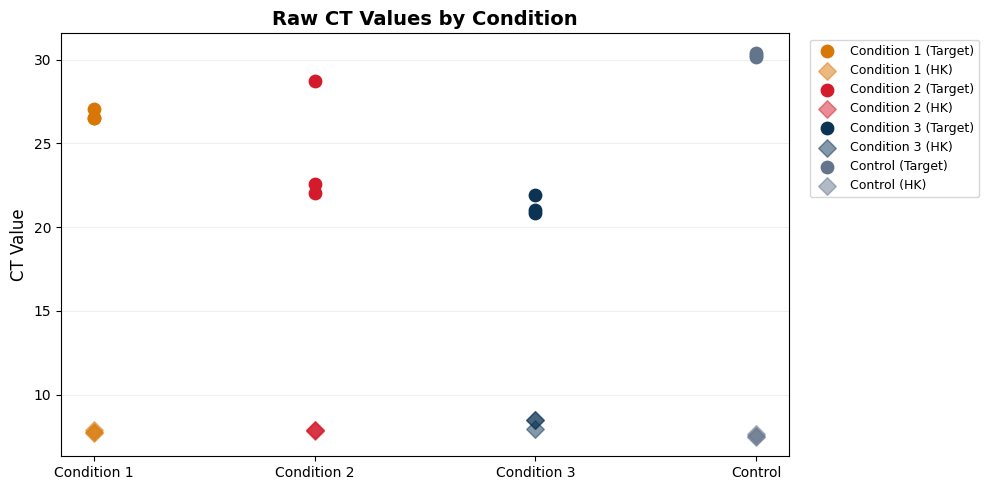

In [23]:
# ── Scatter plot: CT values by condition ──
# Each dot = one biological replicate

fig, ax = plt.subplots(figsize=(10, 5))

colors = {"Control": "#64748B", "Condition 1": "#D97706",
          "Condition 2": "#D41B2C", "Condition 3": "#0C3354"}

for group in piv["group"].unique():
    sub = piv[piv["group"] == group]
    ax.scatter([group]*len(sub), sub["ct_target"],
               c=colors.get(group, "gray"), s=80, label=f"{group} (Target)", zorder=5)
    ax.scatter([group]*len(sub), sub["ct_hk"],
               c=colors.get(group, "gray"), s=80, marker="D", alpha=0.5,
               label=f"{group} (HK)", zorder=5)

ax.set_ylabel("CT Value", fontsize=12)
ax.set_title("Raw CT Values by Condition", fontsize=14, fontweight="bold")
ax.legend(bbox_to_anchor=(1.02, 1), fontsize=9)
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

### 🔍 Data Detective Challenge #2
> Look at the scatter plot above.
>
> **One Target CT point in Condition 2 is far from the other two.**
>
> Which replicate is it? What is its ct_target value?
>
> *Your answer:* Condition 2 Replicate ______ , ct_target = ________


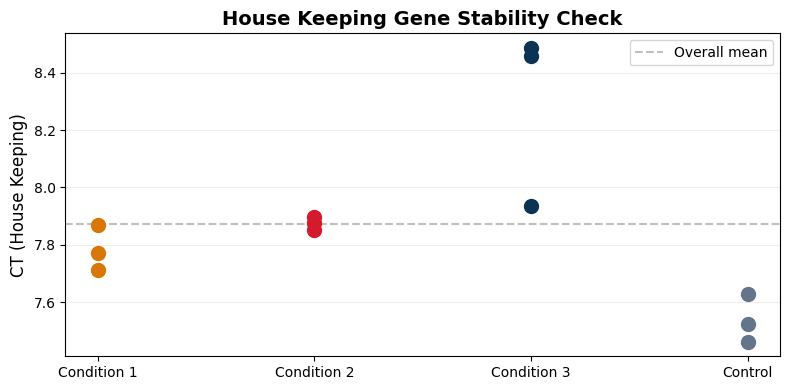

In [24]:
# ── Plot: House Keeping gene stability ──
# HK gene should have ~constant CT across ALL conditions

fig, ax = plt.subplots(figsize=(8, 4))

for group in piv["group"].unique():
    sub = piv[piv["group"] == group]
    # print(sub)
    # print([group]*len(sub))
    ax.scatter([group]*len(sub), sub["ct_hk"],
               c=colors.get(group, "gray"), s=100, zorder=5)

ax.set_ylabel("CT (House Keeping)", fontsize=12)
ax.set_title("House Keeping Gene Stability Check", fontsize=14, fontweight="bold")
ax.axhline(y=piv["ct_hk"].mean(), color="gray", linestyle="--", alpha=0.5, label="Overall mean")
ax.legend()
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

### 🔍 Data Detective Challenge #3
> Does the House Keeping gene look **stable** across all conditions?
>
> If one condition's HK drifts, normalization will be off.
>
> *Your answer:* ________________________________________________


In [25]:
# ── Identify the suspect row ──
# Use filtering to print only Condition 2 Replicate 2

print("Look all Cond 2 replicates:")
print(piv[piv["group"] == "Condition 2"])
print()

print("Show suspect Cond 2 replicate 2:")
cond2r2 = piv[piv["Sample"].str.contains("Condition 2 Replicate 2")]
print("Suspect row:")
print(cond2r2)

Look all Cond 2 replicates:
                    Sample  ct_target     ct_hk        group
3  Condition 2 Replicate 1  22.058591  7.876728  Condition 2
4  Condition 2 Replicate 2  28.731620  7.851026  Condition 2
5  Condition 2 Replicate 3  22.566520  7.897606  Condition 2

Show suspect Cond 2 replicate 2:
Suspect row:
                    Sample  ct_target     ct_hk        group
4  Condition 2 Replicate 2   28.73162  7.851026  Condition 2


---
## Part D: Fix the Source File & Re-Visualize

**The wrong CT value lives in Sample_Data.ods — fix it at the source!**

### Steps:
1. Open `Sample_Data.ods` in LibreOffice Calc (or Excel)
2. Find **Condition 2 Replicate 2** → **Target Gene** row
3. Find the cell with CT value **35.12** (this is the bad value)
4. Replace **35.12** with **22.560**
5. **Save the file** (Ctrl+S)
6. Come back here and re-run the cells below

> **Why 22.560?** The other two Cond 2 Target Gene replicates are 22.04 and 22.34 —
> the value 35.12 is clearly a machine/pipetting error. The correct value from
> the lab notebook is 22.560.

In [26]:
# ── Re-load the corrected file ──
# After saving the fix in the .ods file, re-run this cell

df = pd.read_excel("Sample_Data.ods", engine="odf")

# Fix the Gene spacing issue again
df["Gene"] = df["Gene"].str.strip().str.replace(r"\s+", " ", regex=True)

# Re-process: average → split → merge → group
avg = df.groupby(["Sample", "Gene"])["CT (imported)"].mean().reset_index()
target = avg[avg["Gene"] == "Target Gene"][["Sample", "CT (imported)"]].copy()
target = target.rename(columns={"CT (imported)": "ct_target"})
hk = avg[avg["Gene"] == "House Keeping Gene"][["Sample", "CT (imported)"]].copy()
hk = hk.rename(columns={"CT (imported)": "ct_hk"})
piv = target.merge(hk, on="Sample")
piv["group"] = piv["Sample"].str.replace(r"\s*Replicate.*", "", regex=True)

print("Re-loaded and re-processed ✓")
print(f"{len(piv)} rows ready")

Re-loaded and re-processed ✓
12 rows ready


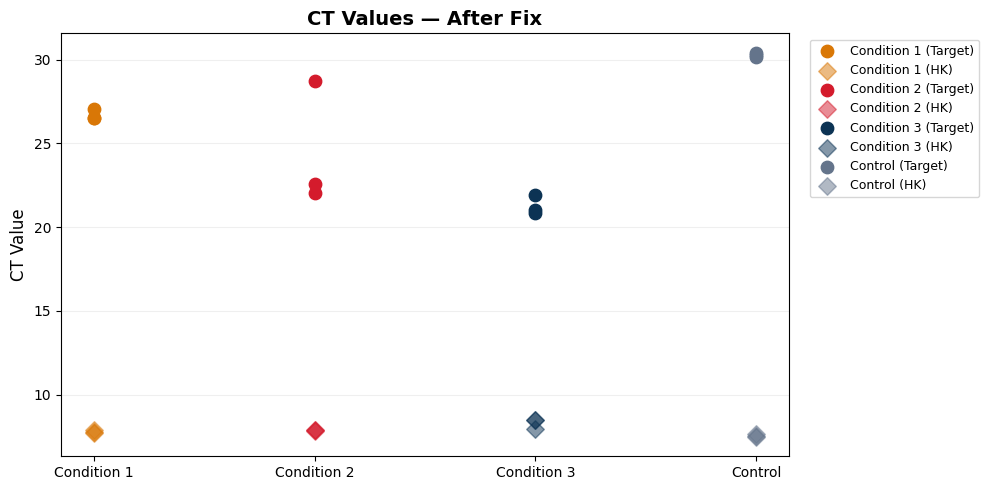


✅ Checkpoint: Cond 2 points should cluster together now.
✅ All HK values should be ~7–9 with no drift.


In [27]:
# ── Re-run the scatter plot — is the outlier gone? ──

fig, ax = plt.subplots(figsize=(10, 5))

for group in piv["group"].unique():
    sub = piv[piv["group"] == group]
    ax.scatter([group]*len(sub), sub["ct_target"],
               c=colors.get(group, "gray"), s=80, label=f"{group} (Target)", zorder=5)
    ax.scatter([group]*len(sub), sub["ct_hk"],
               c=colors.get(group, "gray"), s=80, marker="D", alpha=0.5,
               label=f"{group} (HK)", zorder=5)

ax.set_ylabel("CT Value", fontsize=12)
ax.set_title("CT Values — After Fix", fontsize=14, fontweight="bold")
ax.legend(bbox_to_anchor=(1.02, 1), fontsize=9)
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

print("\n✅ Checkpoint: Cond 2 points should cluster together now.")
print("✅ All HK values should be ~7–9 with no drift.")

---
## Part E: ΔΔCt Calculations
Now we run the 3-step pipeline on the corrected data.

| Step | Formula | What it means |
|------|---------|---------------|
| 1 | ΔCt = Ct(target) − Ct(HK) | Normalize to housekeeping gene |
| 2 | ΔΔCt = ΔCt − mean(ΔCt_control) | Normalize to control condition |
| 3 | 2^(−ΔΔCt) | Convert to fold change |


In [28]:
# ── Step 1: Calculate dCT ──
# dCT = ct_target - ct_housekeeping (per sample)

piv["dCT"] = piv["ct_target"] - piv["ct_hk"]

print("dCT added:")
print(piv[["Sample", "ct_target", "ct_hk", "dCT"]].to_string(index=False))

dCT added:
                 Sample  ct_target    ct_hk       dCT
Condition 1 Replicate 1  27.038250 7.870231 19.168019
Condition 1 Replicate 2  26.535694 7.712414 18.823280
Condition 1 Replicate 3  26.532187 7.772784 18.759403
Condition 2 Replicate 1  22.058591 7.876728 14.181863
Condition 2 Replicate 2  28.731620 7.851026 20.880594
Condition 2 Replicate 3  22.566520 7.897606 14.668914
Condition 3 Replicate 1  20.988827 7.933673 13.055154
Condition 3 Replicate 2  20.816737 8.458871 12.357866
Condition 3 Replicate 3  21.942478 8.486006 13.456472
    Control Replicate 1  30.416238 7.626685 22.789552
    Control Replicate 2  30.142745 7.462405 22.680340
    Control Replicate 3  30.300262 7.523585 22.776677


In [29]:
# ── Practice: Filtering to compute a group mean ──
# Remember the pattern from Part A:
#   df[df["col"] == "value"]["other_col"].mean()
#
# Let's practice: what is the mean dCT for Condition 1?

cond1_mean_dct = piv[piv["group"] == "Condition 1"]["dCT"].mean()
print(f"Mean dCT for Condition 1: {cond1_mean_dct:.3f}")

# Now try: what is the mean dCT for Condition 3?
cond3_mean_dct = piv[piv["group"] == "Condition 3"]["dCT"].mean()
print(f"Mean dCT for Condition 3: {cond3_mean_dct:.3f}")

Mean dCT for Condition 1: 18.917
Mean dCT for Condition 3: 12.956


### ✏️ Your Turn: Compute `control_mean`
Using the **same pattern** as above, compute the mean dCT for the **Control** group.

Replace the `___` with your code.


In [ ]:
# ── Step 2a: Compute control_mean ──
# Same pattern: piv[piv["group"] == "???"]["dCT"].mean()

# YOUR CODE HERE ↓↓↓
ctrl_mean = _____________________________________
# YOUR CODE HERE ↑↑↑

print(f"control_mean = {ctrl_mean:.3f}")
# Should print: 22.749

In [ ]:
# ── Step 2b: Calculate ddCT ──
# Subtract control_mean from every sample's dCT

piv["ddCT"] = piv["dCT"] - ctrl_mean

print("ddCT added — Control values should be ~0:")
print(piv[["Sample", "group", "dCT", "ddCT"]].to_string(index=False))

### ✏️ Your Turn: Compute `2^(-ddCT)`
The fold change formula is: **2 raised to the power of (negative ddCT)**

In Python: `2 ** (-piv["ddCT"])`


In [ ]:
# ── Step 3: Calculate 2^(-ddCT) ──

# YOUR CODE HERE ↓↓↓
piv["2^(-ddCT)"] = _____________________________________
# YOUR CODE HERE ↑↑↑

print("Final table:")
print(piv[["Sample", "dCT", "ddCT", "2^(-ddCT)"]].to_string(index=False))

print()
print('Show piv dataframe:')
piv.head()

---
## Part F: Visualize the Final Results


In [ ]:
# ── Summarize by group ──
# Mean and std of 2^(-ddCT) across biological replicates

summary = piv.groupby("group")["2^(-ddCT)"].agg(["mean", "std", "count"])
print(summary.round(1))

In [ ]:
# ── Bar chart with error bars ──

fig, ax = plt.subplots(figsize=(7, 5))

bar_colors = ["#64748B", "#D97706", "#D41B2C", "#0C3354"]
order = ["Control", "Condition 1", "Condition 2", "Condition 3"]

means = [summary.loc[g, "mean"] if g in summary.index else 0 for g in order]
# print(means)
stds  = [summary.loc[g, "std"]  if g in summary.index else 0 for g in order]
# print(stds)

ax.bar(order, means, yerr=stds, color=bar_colors,
       edgecolor="white", linewidth=1.5, capsize=5)
ax.set_ylabel("2^(-ddCT)", fontsize=13)
ax.set_title("Fold Change by Condition", fontsize=14, fontweight="bold")
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

### 🤔 Interpretation Question
> Which condition shows the **most variability** (widest error bars)?
>
> Why might that be — biological variation or a technical problem?
>
> *Your answer:* ________________________________________________


---
## Part G: Statistical Analysis
Use a **t-test** to check if each condition is significantly different from Control.

`stats.ttest_ind(values_A, values_B)` returns `(t_statistic, p_value)`


In [ ]:
# ── Setup: separate each group's fold-change values ──
# We use the same filtering pattern from earlier

from scipy import stats

ctrl  = piv[piv["group"] == "Control"]["2^(-ddCT)"]
cond1 = piv[piv["group"] == "Condition 1"]["2^(-ddCT)"]
cond2 = piv[piv["group"] == "Condition 2"]["2^(-ddCT)"]
cond3 = piv[piv["group"] == "Condition 3"]["2^(-ddCT)"]

print(f"Control:     n={len(ctrl)}, mean={ctrl.mean():.1f}")
print(f"Condition 1: n={len(cond1)}, mean={cond1.mean():.1f}")
print(f"Condition 2: n={len(cond2)}, mean={cond2.mean():.1f}")
print(f"Condition 3: n={len(cond3)}, mean={cond3.mean():.1f}")

### ✏️ Your Turn: t-test for Condition 1 vs Control
Use `stats.ttest_ind(group1_values, group2_values)`


In [ ]:
# ── t-test: Condition 1 vs Control ──

# YOUR CODE HERE ↓↓↓
t, p = _____________________________________
# YOUR CODE HERE ↑↑↑

print(f"Condition 1 vs Control:")
print(f"  t = {t:.3f},  p = {p:.4f}")
print(f"  {'✅ Significant (p < 0.05)' if p < 0.05 else '❌ Not significant'}")

In [ ]:
# ── t-test: Condition 2 vs Control ──

t, p = stats.ttest_ind(cond2, ctrl)

print(f"Condition 2 vs Control:")
print(f"  t = {t:.3f},  p = {p:.4f}")
print(f"  {'✅ Significant (p < 0.05)' if p < 0.05 else '❌ Not significant'}")

### ✏️ Your Turn: t-test for Condition 3 vs Control


In [ ]:
# ── t-test: Condition 3 vs Control ──

# YOUR CODE HERE ↓↓↓
t, p = _____________________________________
# YOUR CODE HERE ↑↑↑

print(f"Condition 3 vs Control:")
print(f"  t = {t:.3f},  p = {p:.4f}")
print(f"  {'✅ Significant (p < 0.05)' if p < 0.05 else '❌ Not significant'}")

### 🤔 Interpreting the Results

**All three conditions are significantly upregulated vs Control (p < 0.05):**

| Condition | Fold Change | p-value | Significance |
|-----------|-------------|---------|--------------|
| Cond 1    | approx 14×  | 0.0004  | ✅ Strongest p-value |
| Cond 2    | approx 311× | 0.0008  | ✅ Strong |
| Cond 3    | approx 933× | 0.0120  | ✅ Significant, but weakest |

**Two key takeaways:**

**1. One bad value can erase real results.**
Before fixing Sample_Data.ods, Condition 2 showed p = 0.12 (not significant!). A single wrong CT value inflated the
variance so much that the t-test couldn't detect a real difference with n=3.

**2. Significance ≠ magnitude.**
Condition 1 has the *smallest* fold change (approx 14×) but the *strongest* p-value
(0.0004) because its three replicates are tightly clustered (12, 15, 16).
Condition 3 has the *largest* fold change (approx 933×) but the *weakest* p-value
(0.0120) because its replicates are spread out (628, 828, 1343).
**A consistent small effect beats a noisy large effect in statistics.**

---
## Save Your Work


In [ ]:
# ── Save figure and results ──

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(order, means, yerr=stds, color=bar_colors,
       edgecolor="white", linewidth=1.5, capsize=5)
ax.set_ylabel("2^(-ddCT)", fontsize=13)
ax.set_title("Fold Change by Condition", fontsize=14, fontweight="bold")
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig("fold_change.png", dpi=300, bbox_inches="tight")
print("✅ Saved: fold_change.png")

piv.to_csv("qpcr_results.csv", index=False)
print("✅ Saved: qpcr_results.csv")

---
## 🎉 Congratulations!
You've completed the full qPCR analysis pipeline:

1. ✅ Loaded and inspected real data
2. ✅ Found a gene name typo and fixed it
3. ✅ Spotted a bad CT value through visualization
4. ✅ Fixed the source file and verified the fix
5. ✅ Ran the ΔΔCt calculation (dCT → ddCT → 2^(−ddCT))
6. ✅ Visualized fold changes with error bars
7. ✅ Ran statistical tests

**Next step:** Try this pipeline on your own qPCR data!
